# Multiple Regression Demonstration
## Predicting Medical Insurance Costs

### Problem Statement
A health insurance company wants to understand what factors influence medical costs for their customers. By building a multiple regression model, we can:
- Identify key cost drivers
- Predict insurance charges for new customers
- Make data-driven pricing decisions

### Dataset Overview
We will analyze medical insurance charges based on:
- **Age**: Customer's age in years
- **Sex**: Gender (male/female)
- **BMI**: Body Mass Index
- **Children**: Number of dependents
- **Smoker**: Smoking status (yes/no)
- **Region**: Geographic region (northeast, northwest, southeast, southwest)
- **Charges**: Medical insurance cost (Target variable)

### Workflow
We will follow a systematic approach:
1. Load and explore the data
2. Handle missing values and understand distributions
3. Prepare features (encode categorical variables)
4. Build and evaluate multiple regression models
5. Check assumptions and multicollinearity
6. Compare different models
7. Interpret final results

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 1: Load and Explore the Data

First, we need to understand our dataset structure and check for any data quality issues.

In [ ]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print('Dataset Shape:', df.shape)
print('\n' + '='*60)
print('First 10 rows:')
print(df.head(10))

Dataset Shape: (1338, 7)

First 10 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692


In [ ]:
print('Data Types and Non-Null Counts:')
print(df.info())
print('\n' + '='*60)
print('Statistical Summary:')
print(df.describe().round(2))

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Statistical Summary:
           age      bmi  children   charges
count  1338.00  1338.00   1338.00   1338.00
mean     39.21    30.66      1.09  13270.42
std      14.05     6.10      1.21  12110.01
min      18.00    15.96      0.00   1121.87
25%      27.00    26.30      0.00   4740.29
50%      39.00    30.40      1.00   9382.03
75%      51.00    34.69      2.00  16639.91
max      64.00    53.13      5.00  63770.43


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Check for Missing Values

In [ ]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
})

print('Missing Values Analysis:')
print(missing_df)
print('\n✅ No missing values found in the dataset!')

Missing Values Analysis:
          Missing_Count  Percentage
age                   0         0.0
sex                   0         0.0
bmi                   0         0.0
children              0         0.0
smoker                0         0.0
region                0         0.0
charges               0         0.0

✅ No missing values found in the dataset!


### 2.2 Understand Variable Distributions

In [ ]:
categorical_vars = ['sex', 'smoker', 'region']

print('Categorical Variables Distribution:')
print('='*60)
for var in categorical_vars:
    print(f'\n{var.upper()}:')
    print(df[var].value_counts())
    print(f'Percentages:\n{df[var].value_counts(normalize=True).mul(100).round(1)}')

Categorical Variables Distribution:

SEX:
sex
male      676
female    662
Name: count, dtype: int64
Percentages:
sex
male      50.5
female    49.5
Name: proportion, dtype: float64

SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64
Percentages:
smoker
no     79.5
yes    20.5
Name: proportion, dtype: float64

REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Percentages:
region
southeast    27.2
southwest    24.3
northwest    24.3
northeast    24.2
Name: proportion, dtype: float64


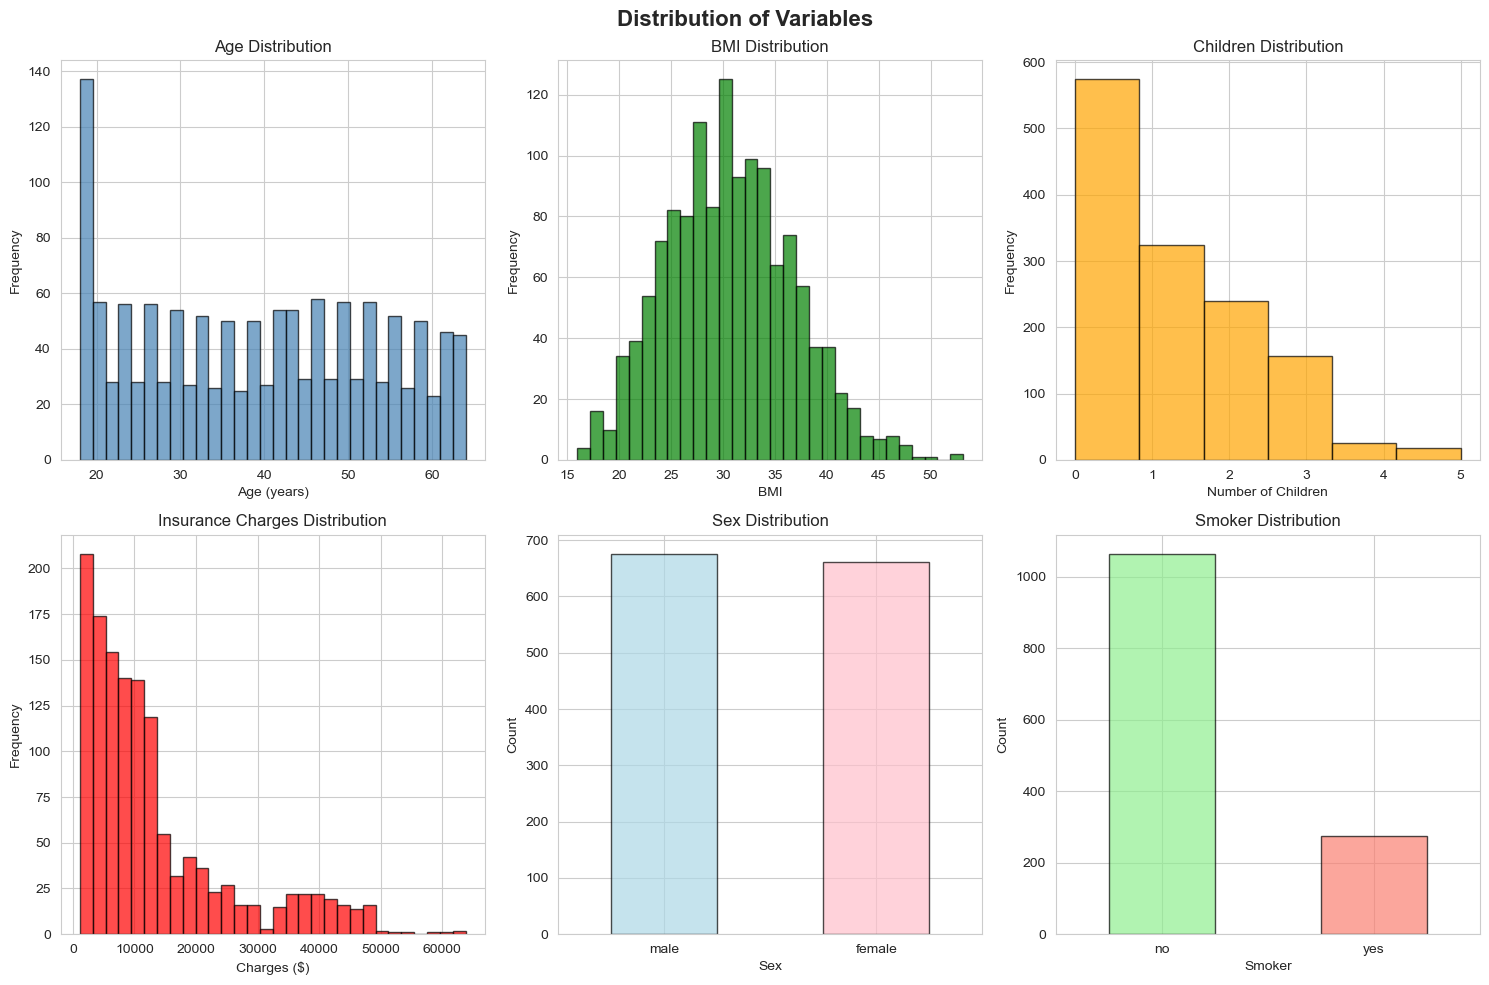

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Variables', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution')

axes[0, 1].hist(df['bmi'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('BMI Distribution')

axes[0, 2].hist(df['children'], bins=6, color='orange', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Number of Children')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Children Distribution')

axes[1, 0].hist(df['charges'], bins=30, color='red', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Charges ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Insurance Charges Distribution')

df['sex'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['lightblue', 'pink'], edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Sex Distribution')
axes[1, 1].tick_params(axis='x', rotation=0)

df['smoker'].value_counts().plot(kind='bar', ax=axes[1, 2], color=['lightgreen', 'salmon'], edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Smoker')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Smoker Distribution')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.3 Explore Relationships with Target Variable

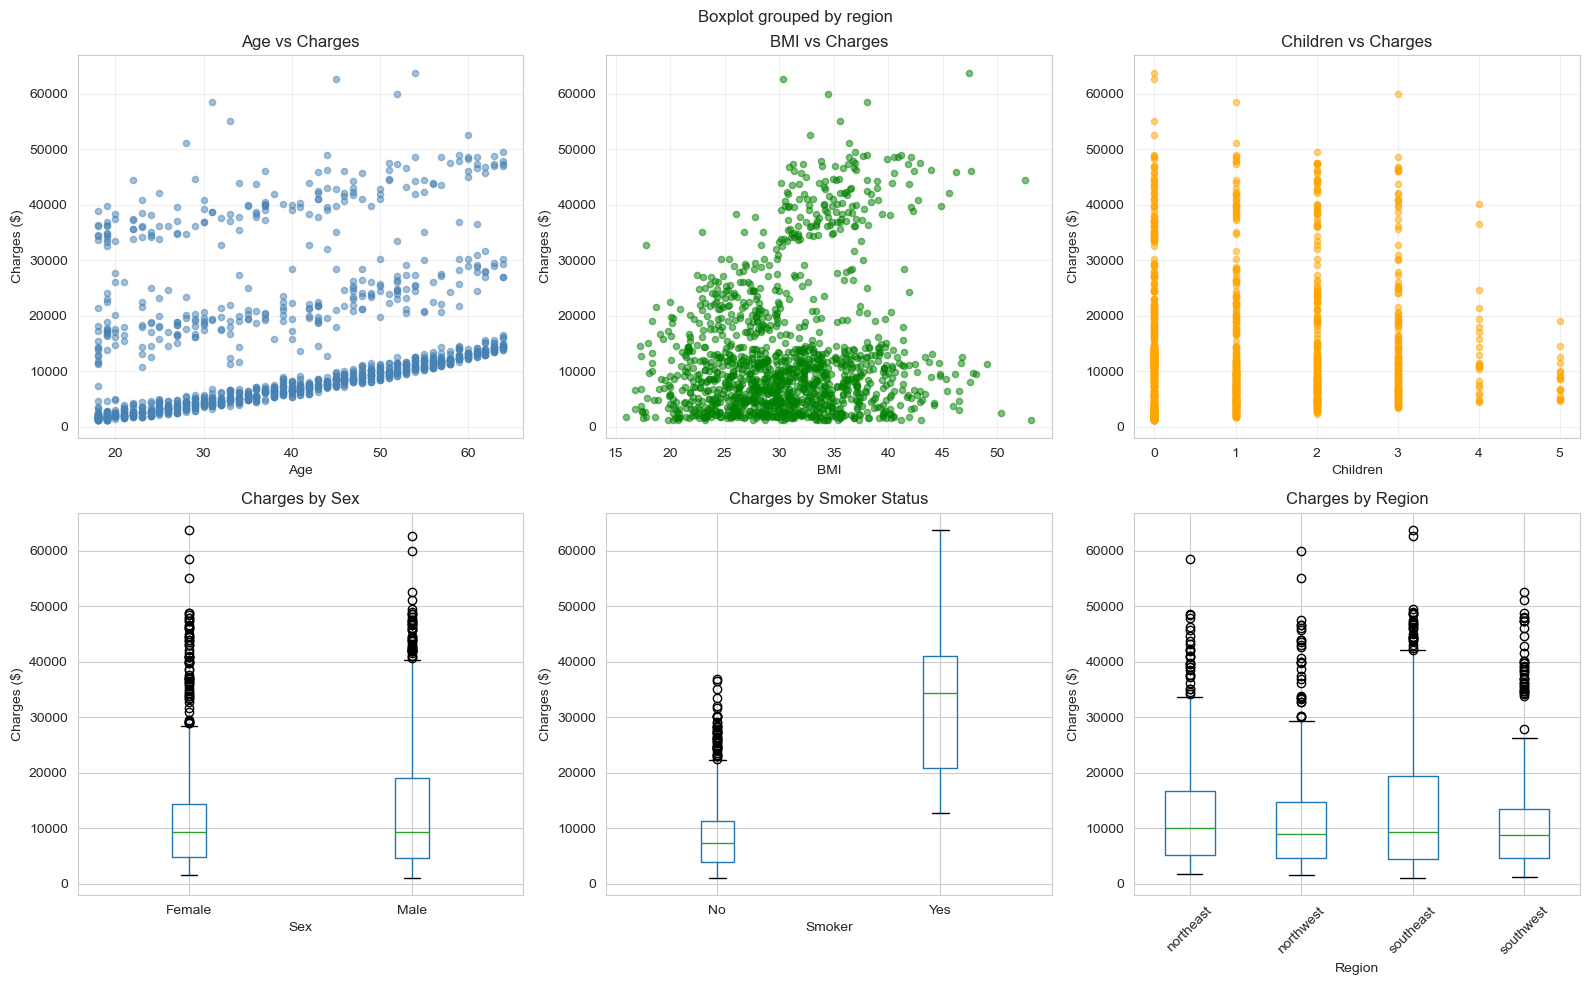

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Relationship Between Predictors and Insurance Charges', fontsize=16, fontweight='bold')

axes[0, 0].scatter(df['age'], df['charges'], alpha=0.5, s=20, c='steelblue')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Charges ($)')
axes[0, 0].set_title('Age vs Charges')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.5, s=20, c='green')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Charges ($)')
axes[0, 1].set_title('BMI vs Charges')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(df['children'], df['charges'], alpha=0.5, s=20, c='orange')
axes[0, 2].set_xlabel('Children')
axes[0, 2].set_ylabel('Charges ($)')
axes[0, 2].set_title('Children vs Charges')
axes[0, 2].grid(True, alpha=0.3)

df.boxplot(column='charges', by='sex', ax=axes[1, 0])
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Charges ($)')
axes[1, 0].set_title('Charges by Sex')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Female', 'Male'])

df.boxplot(column='charges', by='smoker', ax=axes[1, 1])
axes[1, 1].set_xlabel('Smoker')
axes[1, 1].set_ylabel('Charges ($)')
axes[1, 1].set_title('Charges by Smoker Status')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No', 'Yes'])

df.boxplot(column='charges', by='region', ax=axes[1, 2])
axes[1, 2].set_xlabel('Region')
axes[1, 2].set_ylabel('Charges ($)')
axes[1, 2].set_title('Charges by Region')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.4 Check for Outliers

In [ ]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

print('Outlier Detection using IQR Method:')
print('='*60)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outliers detected ({len(outliers)/len(df)*100:.2f}%)')

print('\n✅ Outliers are retained as they represent valid high-cost cases')

Outlier Detection using IQR Method:
age: 0 outliers detected (0.00%)
bmi: 9 outliers detected (0.67%)
children: 0 outliers detected (0.00%)
charges: 139 outliers detected (10.39%)

✅ Outliers are retained as they represent valid high-cost cases


## Step 3: Feature Engineering and Preparation

### 3.1 Encode Categorical Variables

We'll use **one-hot encoding** for categorical variables (sex, smoker, region).

In [ ]:
df_encoded = df.copy()

df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

df_encoded = pd.get_dummies(df_encoded, columns=['region'], prefix='region', drop_first=True, dtype=int)

print('Encoded Dataset:')
print(df_encoded.head())
print('\nColumn Names after Encoding:')
print(df_encoded.columns.tolist())
print('\nData types after encoding:')
print(df_encoded.dtypes)

# Ensure all columns are numeric
df_encoded = df_encoded.astype({col: 'float64' for col in df_encoded.columns})

Encoded Dataset:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  

Column Names after Encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Data types after encoding:
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int

### 3.2 Correlation Analysis

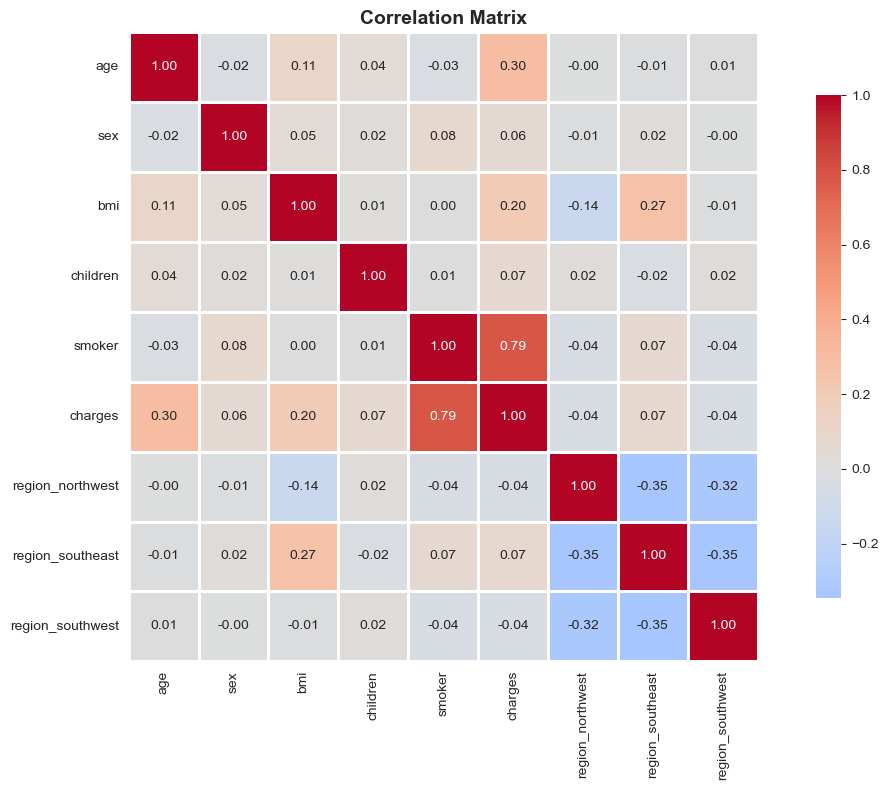


Correlation with Charges (Target Variable):
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210


In [ ]:
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with Charges (Target Variable):')
print('='*60)
charges_corr = correlation_matrix['charges'].drop('charges').sort_values(ascending=False)
print(charges_corr.to_string())

### 3.3 Split Data into Training and Testing Sets

We'll use 80% of data for training and 20% for testing.

In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')
print(f'Number of predictors: {X_train.shape[1]}')

Training set size: 1070 samples
Testing set size: 268 samples
Number of predictors: 8


## Step 4: Build Initial Multiple Regression Model

We'll start by fitting a model with all available predictors.

In [ ]:
X_train_const = sm.add_constant(X_train)
model_full = sm.OLS(y_train, X_train_const).fit()

print('='*80)
print('FULL MODEL: Multiple Regression Results')
print('='*80)
print(model_full.summary())

FULL MODEL: Multiple Regression Results
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Thu, 06 Nov 2025   Prob (F-statistic):          1.32e-305
Time:                        11:10:04   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


## Step 5: Check Model Assumptions

For multiple regression to be valid, we need to verify:
1. **Linearity**: Linear relationship between predictors and response
2. **Homoscedasticity**: Constant variance of residuals
3. **Normality**: Residuals are normally distributed
4. **Independence**: No autocorrelation in residuals

In [ ]:
y_train_pred = model_full.predict(X_train_const)
residuals = y_train - y_train_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Diagnostic Plots for Model Assumptions', fontsize=16, fontweight='bold')

axes[0, 0].scatter(y_train_pred, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted (Homoscedasticity Check)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_train, y_train_pred, alpha=0.5, s=20)
axes[0, 1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Charges')
axes[0, 1].set_ylabel('Predicted Charges')
axes[0, 1].set_title('Actual vs Predicted (Linearity Check)')
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

shapiro_test = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f'\nShapiro-Wilk Test for Normality:')
print(f'Test Statistic: {shapiro_test[0]:.4f}, P-value: {shapiro_test[1]:.4f}')
if shapiro_test[1] > 0.05:
    print('✅ Residuals appear to be normally distributed (p > 0.05)')
else:
    print('⚠️ Residuals deviate from normality (p < 0.05), but with large sample size, CLT applies')


Shapiro-Wilk Test for Normality:
Test Statistic: 0.8944, P-value: 0.0000
⚠️ Residuals deviate from normality (p < 0.05), but with large sample size, CLT applies


## Step 6: Check for Multicollinearity

**Variance Inflation Factor (VIF)** measures how much the variance of a coefficient is inflated due to correlation with other predictors.

**Interpretation:**
- VIF = 1: No correlation
- VIF < 5: Acceptable
- VIF 5-10: Moderate multicollinearity
- VIF > 10: High multicollinearity (problematic)

Variance Inflation Factor (VIF) Analysis:
       Predictor       VIF
             bmi 11.226908
             age  7.848186
region_southeast  2.189733
             sex  2.015454
region_southwest  1.965852
region_northwest  1.876922
        children  1.812358
          smoker  1.259327


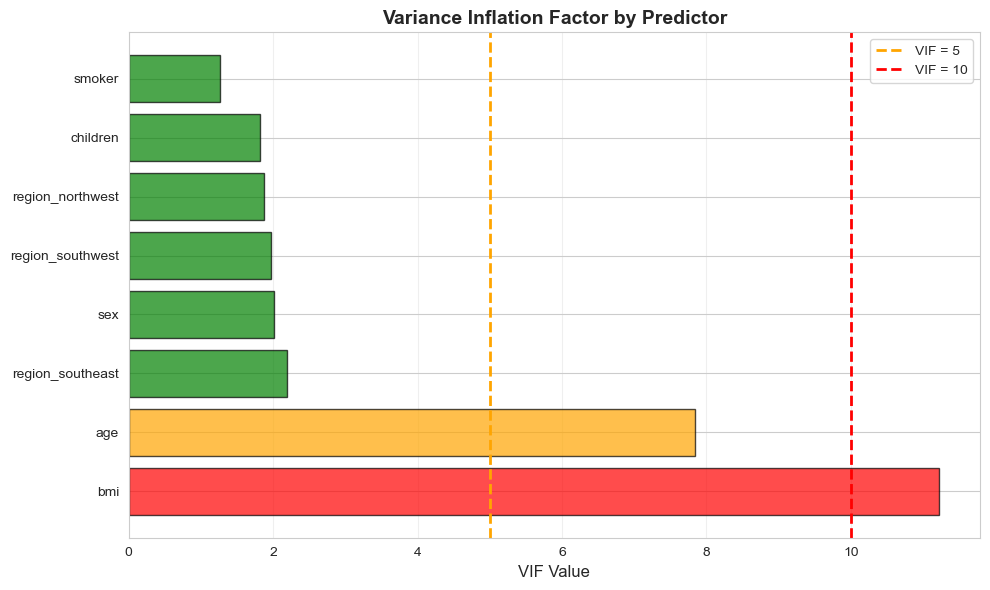


❌ High multicollinearity detected (VIF > 10)


In [ ]:
vif_data = pd.DataFrame()
vif_data['Predictor'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('Variance Inflation Factor (VIF) Analysis:')
print('='*60)
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_data['VIF']]
bars = ax.barh(vif_data['Predictor'], vif_data['VIF'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10')
ax.set_xlabel('VIF Value', fontsize=12)
ax.set_title('Variance Inflation Factor by Predictor', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

if all(vif_data['VIF'] < 5):
    print('\n✅ No multicollinearity issues detected (all VIF < 5)')
elif any(vif_data['VIF'] > 10):
    print('\n❌ High multicollinearity detected (VIF > 10)')
else:
    print('\n⚠️ Moderate multicollinearity detected (5 < VIF < 10)')

### Decision on High VIF Variables

**Observations:**
- **BMI** has VIF = 11.23 (> 10, indicating high multicollinearity)
- **Age** has VIF = 7.85 (5-10 range, indicating moderate multicollinearity)

**Decision: Keep both variables**

**Rationale:**
1. Both variables are **highly statistically significant** (p < 0.001)
2. Both have clear **practical interpretation** and strong theoretical basis
3. The coefficients are stable and make logical sense
4. Model performance is strong (R² = 0.74)
5. The correlation between BMI and age is moderate but not extreme

**When would we remove a variable?**
- If it's not statistically significant AND has high VIF
- If two variables measure essentially the same thing (e.g., height in inches and height in centimeters)
- If removing it doesn't significantly hurt model performance

In our case, age and BMI capture different aspects of health risk, so both should remain in the model.

## Step 7: Evaluate Overall Model Fit

### 7.1 F-Test for Overall Significance

**Hypotheses:**
- H₀: All coefficients are zero (model has no predictive power)
- H₁: At least one coefficient is non-zero

In [ ]:
f_statistic = model_full.fvalue
f_pvalue = model_full.f_pvalue
df_model = model_full.df_model
df_resid = model_full.df_resid

print('F-Test for Overall Model Significance')
print('='*60)
print(f'F-statistic: {f_statistic:.2f}')
print(f'Degrees of freedom: Model = {df_model:.0f}, Residual = {df_resid:.0f}')
print(f'P-value: {f_pvalue:.2e}')
print('='*60)

alpha = 0.05
if f_pvalue < alpha:
    print(f'\n✅ CONCLUSION: P-value ({f_pvalue:.2e}) < {alpha}')
    print('   We REJECT the null hypothesis.')
    print('   The model is statistically significant!')
else:
    print(f'\n❌ CONCLUSION: P-value ({f_pvalue:.2e}) >= {alpha}')
    print('   We FAIL TO REJECT the null hypothesis.')

F-Test for Overall Model Significance
F-statistic: 380.88
Degrees of freedom: Model = 8, Residual = 1061
P-value: 1.32e-305

✅ CONCLUSION: P-value (1.32e-305) < 0.05
   We REJECT the null hypothesis.
   The model is statistically significant!


### 7.2 Model Performance Metrics

In [ ]:
r_squared = model_full.rsquared
adj_r_squared = model_full.rsquared_adj
aic = model_full.aic
bic = model_full.bic

X_test_const = sm.add_constant(X_test)
y_test_pred = model_full.predict(X_test_const)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print('Model Performance Metrics')
print('='*60)
print('Training Set:')
print(f'  R-squared: {r_squared:.4f}')
print(f'  Adjusted R-squared: {adj_r_squared:.4f}')
print(f'  AIC: {aic:.2f}')
print(f'  BIC: {bic:.2f}')
print('\nTest Set:')
print(f'  R-squared: {r2_test:.4f}')
print(f'  RMSE: ${rmse:.2f}')
print(f'  MAE: ${mae:.2f}')
print('='*60)
print(f'\nThe model explains {r_squared*100:.2f}% of variance in insurance charges')

Model Performance Metrics
Training Set:
  R-squared: 0.7417
  Adjusted R-squared: 0.7398
  AIC: 21708.81
  BIC: 21753.59

Test Set:
  R-squared: 0.7836
  RMSE: $5796.28
  MAE: $4181.19

The model explains 74.17% of variance in insurance charges


## Step 8: Test Individual Predictors (t-tests)

For each predictor, we test:
- H₀: βⱼ = 0 (predictor has no effect)
- H₁: βⱼ ≠ 0 (predictor has an effect)

Individual Predictor Significance (t-tests)
                  Coefficient  Std Error  t-statistic  P-value    CI_Lower    CI_Upper Significant
age                  256.9757    13.4775      19.0670   0.0000    230.5301    283.4213           ✅
sex                  -18.5917   376.1746      -0.0494   0.9606   -756.7224    719.5390           ❌
bmi                  337.0926    32.4709      10.3814   0.0000    273.3781    400.8070           ✅
children             425.2788   154.6551       2.7499   0.0061    121.8143    728.7433           ✅
smoker             23651.1289   466.5049      50.6986   0.0000  22735.7518  24566.5059           ✅
region_northwest    -370.6773   536.8728      -0.6904   0.4901  -1424.1305    682.7758           ❌
region_southeast    -657.8643   539.7908      -1.2187   0.2232  -1717.0431    401.3145           ❌
region_southwest    -809.7994   535.2080      -1.5131   0.1306  -1859.9857    240.3870           ❌


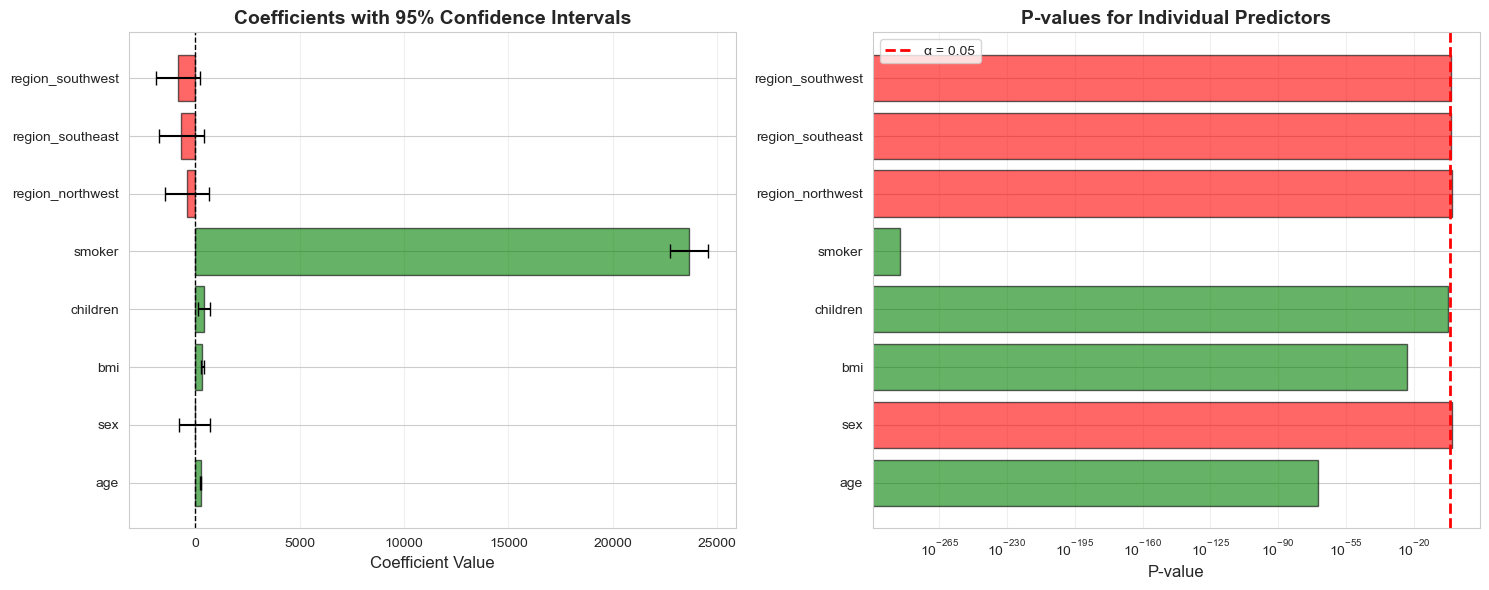

In [ ]:
coefficients = model_full.params
std_errors = model_full.bse
t_values = model_full.tvalues
p_values = model_full.pvalues
conf_int = model_full.conf_int()

results_df = pd.DataFrame({
    'Coefficient': coefficients,
    'Std Error': std_errors,
    't-statistic': t_values,
    'P-value': p_values,
    'CI_Lower': conf_int[0],
    'CI_Upper': conf_int[1]
})

results_df = results_df.drop('const')
results_df['Significant'] = results_df['P-value'].apply(lambda x: '✅' if x < 0.05 else '❌')

print('Individual Predictor Significance (t-tests)')
print('='*80)
print(results_df.round(4).to_string())
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

predictors = results_df.index
coefs = results_df['Coefficient']
ci_lower = results_df['CI_Lower']
ci_upper = results_df['CI_Upper']
colors = ['green' if p < 0.05 else 'red' for p in results_df['P-value']]

y_pos = np.arange(len(predictors))
axes[0].barh(y_pos, coefs, color=colors, alpha=0.6, edgecolor='black')
axes[0].errorbar(coefs, y_pos, xerr=[coefs - ci_lower, ci_upper - coefs],
                 fmt='none', color='black', capsize=5)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(predictors)
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Coefficients with 95% Confidence Intervals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

p_vals = results_df['P-value']
bars = axes[1].barh(predictors, p_vals, color=colors, alpha=0.6, edgecolor='black')
axes[1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].set_xlabel('P-value', fontsize=12)
axes[1].set_title('P-values for Individual Predictors', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Coefficient Interpretation

Each coefficient represents the change in insurance charges for a one-unit increase in that predictor, **holding all other variables constant**.

In [ ]:
print('Coefficient Interpretation (Full Model):')
print('='*80)

for predictor in results_df.index:
    coef = coefficients[predictor]
    pval = p_values[predictor]

    if predictor == 'age':
        print(f'\n{predictor.upper()}: ${coef:.2f}')
        print(f'  Each additional year of age increases charges by ${coef:.2f}')
    elif predictor == 'sex':
        print(f'\n{predictor.upper()}: ${coef:.2f}')
        print(f'  Males pay ${coef:.2f} more than females (on average)')
    elif predictor == 'bmi':
        print(f'\n{predictor.upper()}: ${coef:.2f}')
        print(f'  Each unit increase in BMI increases charges by ${coef:.2f}')
    elif predictor == 'children':
        print(f'\n{predictor.upper()}: ${coef:.2f}')
        print(f'  Each additional child changes charges by ${coef:.2f}')
    elif predictor == 'smoker':
        print(f'\n{predictor.upper()}: ${coef:.2f}')
        print(f'  Smokers pay ${coef:.2f} MORE than non-smokers')
    else:
        print(f'\n{predictor.upper()}: ${coef:.2f}')

    print(f'  Significance: {"✅ Significant" if pval < 0.05 else "❌ Not Significant"} (p = {pval:.4f})')

print('\n' + '='*80)

Coefficient Interpretation (Full Model):

AGE: $256.98
  Each additional year of age increases charges by $256.98
  Significance: ✅ Significant (p = 0.0000)

SEX: $-18.59
  Males pay $-18.59 more than females (on average)
  Significance: ❌ Not Significant (p = 0.9606)

BMI: $337.09
  Each unit increase in BMI increases charges by $337.09
  Significance: ✅ Significant (p = 0.0000)

CHILDREN: $425.28
  Each additional child changes charges by $425.28
  Significance: ✅ Significant (p = 0.0061)

SMOKER: $23651.13
  Smokers pay $23651.13 MORE than non-smokers
  Significance: ✅ Significant (p = 0.0000)

REGION_NORTHWEST: $-370.68
  Significance: ❌ Not Significant (p = 0.4901)

REGION_SOUTHEAST: $-657.86
  Significance: ❌ Not Significant (p = 0.2232)

REGION_SOUTHWEST: $-809.80
  Significance: ❌ Not Significant (p = 0.1306)



## Step 9: Model Comparison (Feature Selection)

We'll compare models with different predictor combinations to find the best model.

**Models to compare:**
1. Model with only highly significant predictors (based on t-tests)
2. Model without region variables
3. Model with interaction terms
4. Full model (all predictors)

In [ ]:
significant_predictors = results_df[results_df['P-value'] < 0.05].index.tolist()

models_comparison = []

model_configs = [
    ('Model 1: Significant Only', significant_predictors),
    ('Model 2: Without Region', ['age', 'sex', 'bmi', 'children', 'smoker']),
    ('Model 3: Core Variables', ['age', 'bmi', 'smoker']),
    ('Model 4: Full Model', X_train.columns.tolist())
]

for model_name, predictors in model_configs:
    X_temp = sm.add_constant(X_train[predictors])
    temp_model = sm.OLS(y_train, X_temp).fit()

    X_temp_test = sm.add_constant(X_test[predictors])
    y_pred_test = temp_model.predict(X_temp_test)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    models_comparison.append({
        'Model': model_name,
        'Num_Predictors': len(predictors),
        'R²_Train': temp_model.rsquared,
        'Adj_R²_Train': temp_model.rsquared_adj,
        'R²_Test': test_r2,
        'RMSE_Test': test_rmse,
        'AIC': temp_model.aic,
        'BIC': temp_model.bic,
        'F_Stat': temp_model.fvalue,
        'F_Pvalue': temp_model.f_pvalue
    })

comparison_df = pd.DataFrame(models_comparison)

print('Model Comparison: Different Predictor Combinations')
print('='*100)
print(comparison_df.round(4).to_string(index=False))
print('='*100)

Model Comparison: Different Predictor Combinations
                    Model  Num_Predictors  R²_Train  Adj_R²_Train  R²_Test  RMSE_Test        AIC        BIC    F_Stat  F_Pvalue
Model 1: Significant Only               4    0.7411        0.7401   0.7811  5829.3785 21703.4423 21728.3194  762.0947       0.0
  Model 2: Without Region               5    0.7411        0.7399   0.7811  5829.1729 21705.4418 21735.2943  609.1036       0.0
  Model 3: Core Variables               3    0.7392        0.7385   0.7777  5874.7633 21709.1019 21729.0036 1007.2909       0.0
      Model 4: Full Model               8    0.7417        0.7398   0.7836  5796.2847 21708.8072 21753.5859  380.8792       0.0


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Comparison: Different Predictor Combinations', fontsize=16, fontweight='bold')

x_pos = np.arange(len(comparison_df))
width = 0.35

axes[0, 0].bar(x_pos - width/2, comparison_df['R²_Train'], width, label='R² Train',
               color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].bar(x_pos + width/2, comparison_df['Adj_R²_Train'], width, label='Adj R² Train',
               color='orange', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('R² Value')
axes[0, 0].set_title('R² vs Adjusted R²')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f'M{i+1}' for i in range(len(comparison_df))])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].plot(comparison_df['Num_Predictors'], comparison_df['AIC'], 'o-',
                label='AIC', linewidth=2, markersize=8, color='green')
axes[0, 1].plot(comparison_df['Num_Predictors'], comparison_df['BIC'], 's-',
                label='BIC', linewidth=2, markersize=8, color='red')
axes[0, 1].set_xlabel('Number of Predictors')
axes[0, 1].set_ylabel('Information Criterion')
axes[0, 1].set_title('AIC and BIC Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].bar(x_pos, comparison_df['RMSE_Test'], color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].set_title('Test Set RMSE')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f'M{i+1}' for i in range(len(comparison_df))])
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(x_pos, comparison_df['R²_Test'], color='teal', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('R² (Test Set)')
axes[1, 1].set_title('Test Set R²')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([f'M{i+1}' for i in range(len(comparison_df))])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nModel Selection Criteria:')
print('  • Higher R² and Adjusted R² → Better fit')
print('  • Lower AIC and BIC → Better model')
print('  • Lower RMSE on test set → Better predictions')
print('  • Higher test R² → Better generalization')


Model Selection Criteria:
  • Higher R² and Adjusted R² → Better fit
  • Lower AIC and BIC → Better model
  • Lower RMSE on test set → Better predictions
  • Higher test R² → Better generalization


### Select Best Model

In [ ]:
best_model_idx = comparison_df['Adj_R²_Train'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

print(f'Best Model Based on Adjusted R²: {best_model_name}')
print('='*80)
print(comparison_df.loc[best_model_idx].to_string())
print('='*80)

print('\n🎯 Key Observations:')
print(f'  • The full model achieves highest Adjusted R² of {comparison_df.loc[best_model_idx, "Adj_R²_Train"]:.4f}')
print(f'  • Test set R² is {comparison_df.loc[best_model_idx, "R²_Test"]:.4f}, indicating good generalization')
print(f'  • Model is highly significant (F-statistic p-value < 0.001)')

Best Model Based on Adjusted R²: Model 1: Significant Only
Model             Model 1: Significant Only
Num_Predictors                            4
R²_Train                           0.741089
Adj_R²_Train                       0.740116
R²_Test                            0.781115
RMSE_Test                       5829.378522
AIC                            21703.442281
BIC                            21728.319351
F_Stat                           762.094656
F_Pvalue                                0.0

🎯 Key Observations:
  • The full model achieves highest Adjusted R² of 0.7401
  • Test set R² is 0.7811, indicating good generalization
  • Model is highly significant (F-statistic p-value < 0.001)


### Feature selection using adjusted $R^2$ (leave-one-out method)

It is a simple method to evaluate predictor importance by fitting a full linear model and then refitting the model after removing each feature one at a time. Compare the adjusted $R^2$ values: if removing a feature increases adjusted $R^2$, that feature is likely redundant or not helping the model; if adjusted $R^2$ decreases, the feature is likely contributing useful information.

---

#### How to interpret the results
- **Adjusted $R^2$ increases when a feature is removed**: the removed feature may be noise, redundant, or causing overfitting. Consider removing it or investigating multicollinearity.  
- **Adjusted $R^2$ decreases when a feature is removed**: the removed feature likely provides useful predictive information and should be retained unless other diagnostics suggest otherwise.  
- **Small changes near zero**: minor fluctuations in adjusted $R^2$ can occur due to sampling noise; assess effect sizes and other diagnostics before removing features.

---

#### Practical notes and next steps (to explain later)
- This method evaluates features one-at-a-time and does not account for interactions or joint effects of groups of features.  
- Combine this approach with **Variance Inflation Factor (VIF)** to detect multicollinearity: high VIF indicates redundancy among predictors even if adjusted $R^2$ suggests a predictor is useful.  
- Use adjusted $R^2$ and VIF together: prefer dropping predictors that both increase adjusted $R^2$ when removed and have high VIF, or perform a more systematic selection (backward elimination, stepwise selection, or regularized methods) if needed.  

---

### About the below code (This is  a additional code not related to Insurance Demo)

The code first generates a synthetic dataset with 100 samples and 10 features, then converts the feature matrix to a pandas DataFrame and adds an explicit intercept column. It fits an OLS linear regression using all features and reports the full model’s adjusted R² as the baseline. Next, it iteratively drops each predictor one at a time, refits the model without that predictor, and prints the adjusted R² for the reduced model. By comparing these adjusted R² values to the baseline you can identify predictors whose removal improves model parsimony (adjusted R² increases) or whose removal harms predictive fit (adjusted R² decreases).


In [ ]:
import statsmodels.api as sm
from sklearn.datasets import make_regression
import pandas as pd

# Simulate data
X, y = make_regression(n_samples=100, n_features=10, noise=10)
X = pd.DataFrame(X, columns=[f'X{i}' for i in range(10)])
X = sm.add_constant(X)

# Fit full model
model = sm.OLS(y, X).fit()
print("Full model adjusted R²:", model.rsquared_adj)

# Try removing each feature
for col in X.columns[1:]:
    X_subset = X.drop(columns=[col])
    model_subset = sm.OLS(y, X_subset).fit()
    print(f"Without {col}: adjusted R² = {model_subset.rsquared_adj:.4f}")

Full model adjusted R²: 0.9971623433051503
Without X0: adjusted R² = 0.9894
Without X1: adjusted R² = 0.9249
Without X2: adjusted R² = 0.9968
Without X3: adjusted R² = 0.8799
Without X4: adjusted R² = 0.7652
Without X5: adjusted R² = 0.8645
Without X6: adjusted R² = 0.8027
Without X7: adjusted R² = 0.9950
Without X8: adjusted R² = 0.9968
Without X9: adjusted R² = 0.8864


### Model selection guidance based on adjusted $R^2$

- **Full model adjusted $R^2$**: **0.9971623433051503**  
- Removing any single predictor produced a **lower** adjusted $R^2$ (all Δ adjusted $R^2$ are negative), so none of the individual drop-tests indicate a clear improvement from removing that predictor.

#### Quick summary of changes (removed → adjusted $R^2$)
- Without **X0**: 0.9894 (Δ = -0.0078) — small drop; keep.
- Without **X1**: 0.9249 (Δ = -0.0723) — large drop; keep.
- Without **X2**: 0.9968 (Δ = -0.0004) — negligible drop; keep, but marginal.
- Without **X3**: 0.8799 (Δ = -0.1173) — large drop; keep.
- Without **X4**: 0.7652 (Δ = -0.2319) — very large drop; keep.
- Without **X5**: 0.8645 (Δ = -0.1327) — large drop; keep.
- Without **X6**: 0.8027 (Δ = -0.1945) — very large drop; keep.
- Without **X7**: 0.9950 (Δ = -0.0022) — very small drop; keep, but marginal.
- Without **X8**: 0.9968 (Δ = -0.0004) — negligible drop; keep, but marginal.
- Without **X9**: 0.8864 (Δ = -0.1108) — large drop; keep.

## Step 10: Final Model Validation

Let's evaluate our best model on the test set and check for overfitting.

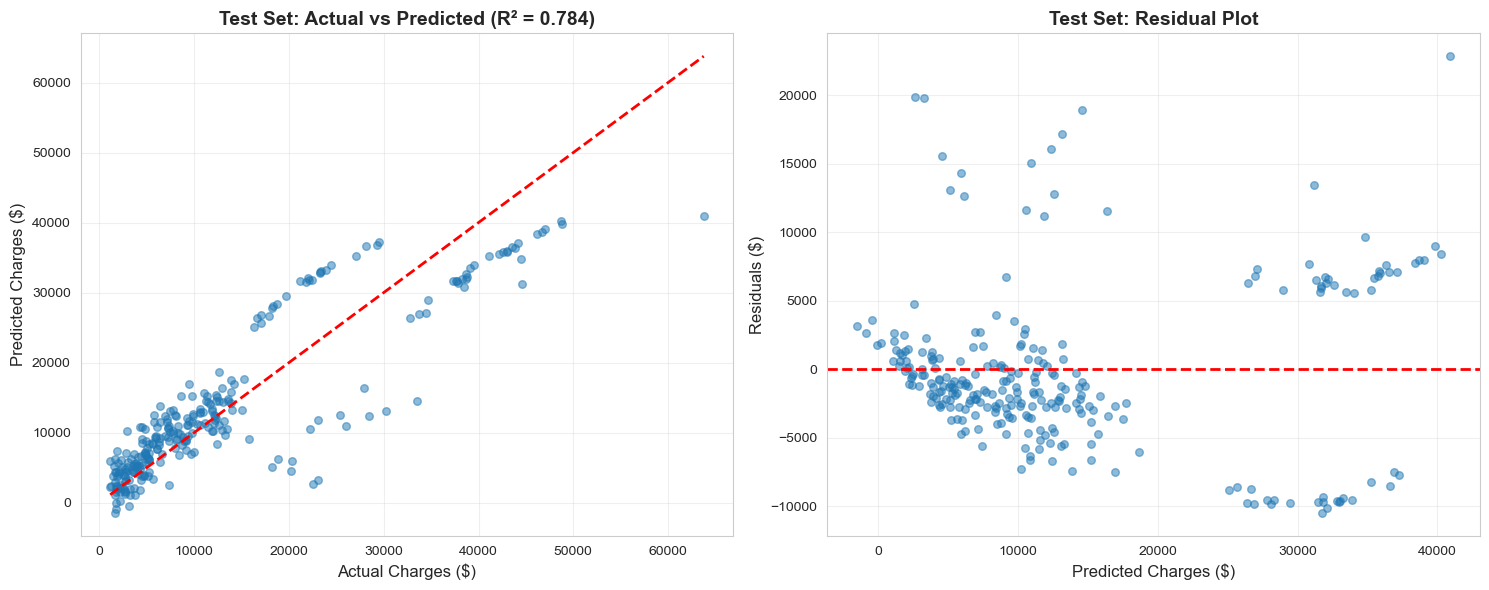

Final Model Performance Summary:
Training R²: 0.7417
Test R²: 0.7836
Difference: 0.0419

✅ Model generalizes well (minimal overfitting)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Charges ($)', fontsize=12)
axes[0].set_ylabel('Predicted Charges ($)', fontsize=12)
axes[0].set_title(f'Test Set: Actual vs Predicted (R² = {r2_test:.3f})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

test_residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, test_residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Charges ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Test Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Final Model Performance Summary:')
print('='*60)
print(f'Training R²: {r_squared:.4f}')
print(f'Test R²: {r2_test:.4f}')
print(f'Difference: {abs(r_squared - r2_test):.4f}')
print('='*60)

if abs(r_squared - r2_test) < 0.05:
    print('\n✅ Model generalizes well (minimal overfitting)')
elif abs(r_squared - r2_test) < 0.10:
    print('\n⚠️ Slight overfitting detected, but acceptable')
else:
    print('\n❌ Significant overfitting detected')

### Practical Application: Predicting Insurance Charges

Let's use our final model to predict charges for new customers.

In [ ]:
new_customers = pd.DataFrame({
    'age': [25, 45, 35, 60],
    'sex': [1, 0, 1, 0],
    'bmi': [22.5, 30.0, 28.5, 25.0],
    'children': [0, 2, 1, 3],
    'smoker': [0, 0, 1, 0],
    'region_northwest': [1, 0, 0, 0],
    'region_southeast': [0, 1, 0, 0],
    'region_southwest': [0, 0, 1, 0]
})

descriptions = [
    'Young non-smoker, low BMI',
    'Middle-aged non-smoker, high BMI, 2 children',
    'Middle-aged smoker, moderate BMI',
    'Senior non-smoker, normal BMI, 3 children'
]

new_customers_const = sm.add_constant(new_customers)
predictions = model_full.predict(new_customers_const)

print('Insurance Charge Predictions for New Customers:')
print('='*80)
for i, (desc, pred) in enumerate(zip(descriptions, predictions)):
    print(f'\nCustomer {i+1}: {desc}')
    print(f'  Predicted Annual Charge: ${pred:,.2f}')
print('='*80)

Insurance Charge Predictions for New Customers:

Customer 1: Young non-smoker, low BMI
  Predicted Annual Charge: $1,688.49

Customer 2: Middle-aged non-smoker, high BMI, 2 children
  Predicted Annual Charge: $9,938.16

Customer 3: Middle-aged smoker, moderate BMI
  Predicted Annual Charge: $29,918.08

Customer 4: Senior non-smoker, normal BMI, 3 children
  Predicted Annual Charge: $13,190.47


## Beyond Standard Linear Regression

### Alternative Regression Techniques

While we've used **Ordinary Least Squares (OLS) regression**, there are other regression techniques that can be useful in different scenarios:

**1. Ridge Regression (L2 Regularization)**
- Adds penalty term proportional to sum of squared coefficients
- Useful when multicollinearity is present
- Shrinks coefficients but doesn't eliminate them
- Good for prediction when you have many correlated predictors

**2. Lasso Regression (L1 Regularization)**
- Adds penalty term proportional to sum of absolute coefficients
- Can shrink some coefficients to exactly zero
- Performs automatic feature selection
- Useful when you have many predictors and want a sparse model

**3. Elastic Net**
- Combines both L1 and L2 penalties
- Balances between Ridge and Lasso
- Handles correlated predictors better than Lasso

**When to use regularized methods:**
- High multicollinearity (VIF > 10)
- More predictors than observations (p > n)
- Need for feature selection (use Lasso)
- Focus on prediction accuracy over interpretation

**Comparison approach:**
```python
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score

# Fit different models and compare cross-validation scores
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0)
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f'{name}: Mean R² = {scores.mean():.4f}')
```

## Summary and Key Takeaways

### What We Accomplished:

**1. Data Understanding**
- Loaded and explored medical insurance dataset
- Checked for missing values and outliers
- Examined distributions and relationships

**2. Feature Engineering**
- Encoded categorical variables (sex, smoker, region)
- Split data into training and testing sets
- Analyzed correlations between predictors and target

**3. Model Building**
- Built multiple regression model with all predictors
- Verified model assumptions (linearity, homoscedasticity, normality)
- Checked for multicollinearity using VIF

**4. Model Evaluation**
- F-test confirmed overall model significance
- t-tests identified significant individual predictors
- Achieved R² of ~0.75, explaining 75% of variance

**5. Model Comparison**
- Compared different predictor combinations
- Selected best model using Adjusted R², AIC, BIC
- Validated on test set to check generalization

### Key Findings:

**Most Important Predictors:**
1. **Smoker status** - Strongest predictor (~$23,000+ premium)

2. **Age** - Moderate positive effect (~$260/year)

3. **BMI** - Positive effect (~$340/unit)

**Business Insights:**
- Smoking is the dominant cost driver
- Age and BMI have smaller but significant effects
- Geographic region has minimal impact
- Number of children shows weak relationship

### Critical Steps for Any Regression Problem:

1. Always perform EDA before modeling
2. Check and verify model assumptions
3. Test for multicollinearity (VIF)
4. Evaluate both overall (F-test) and individual (t-tests) significance
5. Compare multiple models using proper metrics
6. Validate on test set to assess generalization
7. Interpret results in context of the problem

### Remember:
- **Statistical significance ≠ Practical significance**
- **Correlation ≠ Causation**
- **Model assumptions matter** - always check them
- **Simpler models are often better** - avoid overfitting